# CAPSTONE: Pardavimų ir klientų elgsenos analizė (Supermarket Sales)

## Projekto tikslas

Pritaikyti pagrindinius duomenų analizės, statistikos ir modeliavimo metodus, atliekant pilną
analizės ciklą nuo duomenų apžvalgos iki statistinių išvadų ir prognozavimo Python aplinkoje.

Analizės ciklą sudaro **duomenų supratimas**, **EDA**, **pasikliautiniai intervalai**, **hipotezių testavimas**
ir dvi analitinės dalys: **regresija** ir **laiko eilučių analizė**.

## Duomenų rinkinys

**Supermarket Sales Dataset (Kaggle)**

https://www.kaggle.com/datasets/faresashraf1001/supermarket-sales

## Išpildyti techniniai reikalavimai:

- Analitinis darbas pateiktas **Jupyter Notebook** formatu (.ipynb), o analitinės
  išvados - kartu ir PDF bei MS Word formatais.
- Kodas didžiąja dalimi yra tvarkingas ir nuoseklus.
- Visi rezultatai paaiškinti tekstu.
- Akcentuotas aiškumas ir teisinga logika, kuriama vertė verslui.

#### Išvengta dažnų klaidų:

- Po `pd.get_dummies(...)` pritaikyta `.astype(float)`, kad OLS modelis veiktų be klaidų (`ValueError`).
- Test rinkinys nebuvo naudotas modelio pasirinkimui (jei buvo lyginami variantai, sprendimas priimtas pagal train/validation arba aiškiai aprašytas).
- Visi grafikai turi pavadinimus ir ašių pavadinimus.
- Po statistinių testų pateikta ne tik p reikšmė, bet ir praktinis efektas (pvz., vidurkių skirtumas).
- Nepalikta neužkomentuotų kodo nuotrupų, tarpinių skaičiavimų. 

## Analizės etapai

---

###  Aplinkos paruošimas

- Importuojamos pagrindinės bibliotekos.
- Užtikrinama, kad grafikai būtų aiškūs (pavadinimai, ašys).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# For regression:
import statsmodels.api as sm
from scipy import stats
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True

---

### Duomenų įkėlimas

- Įkeliamas CSV failas.
- Patikrinama, ar DataFrame objektas `df` egzistuoja ir ar matomos pirmosios eilutės.

In [2]:
df = pd.read_csv("SuperMarket Analysis.csv")
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


---

### 1. Duomenų supratimas ir paruošimas

**Tikslas:**
- Patikrinti duomenų dydį (`shape`) ir stulpelių pavadinimus.
- Patikrinti duomenų tipus (`info`).
- Patikrinti trūkstamas reikšmes (missing values).
- Jei yra datos stulpelis (pvz., `Date`), konvertuoti į `datetime`.
- Jei reikia, sutvarkyti netinkamus duomenų tipus.
- Patikrinti, ar nėra kitų akivaizdžių duomenų problemų.
- Pateikti trumpą tekstinį aprašymą ir bazinę duomenų apžvalgą.

### Sprendimas:

Duomenų rinkinio eilučių ir stulpelių skaičius:

In [3]:
df.shape

(1000, 17)

Stulpelių pavadinimai:

In [4]:
df.columns.tolist()

['Invoice ID',
 'Branch',
 'City',
 'Customer type',
 'Gender',
 'Product line',
 'Unit price',
 'Quantity',
 'Tax 5%',
 'Sales',
 'Date',
 'Time',
 'Payment',
 'cogs',
 'gross margin percentage',
 'gross income',
 'Rating']

Bendra informacija apie duomenis:

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   str    
 1   Branch                   1000 non-null   str    
 2   City                     1000 non-null   str    
 3   Customer type            1000 non-null   str    
 4   Gender                   1000 non-null   str    
 5   Product line             1000 non-null   str    
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Sales                    1000 non-null   float64
 10  Date                     1000 non-null   str    
 11  Time                     1000 non-null   str    
 12  Payment                  1000 non-null   str    
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  1000 non-nu

Duomenų tipai kiekviename stulpelyje:

In [6]:
df.dtypes

Invoice ID                     str
Branch                         str
City                           str
Customer type                  str
Gender                         str
Product line                   str
Unit price                 float64
Quantity                     int64
Tax 5%                     float64
Sales                      float64
Date                           str
Time                           str
Payment                        str
cogs                       float64
gross margin percentage    float64
gross income               float64
Rating                     float64
dtype: object

Duomenys neturi trūkstamų reikšmių:

In [7]:
df.isna().sum().sort_values(ascending=False)

Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Sales                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64

Konvertuojama data į `datetime` tipą.
Sukuriamas atskiras datos ir laiko (`Datetime`) stulpelis, iškart po `Date` ir `Time` stulpelių.
Pasirinktinai, `Date` ir `Time` stulpeliai gali būti panaikinti:

In [8]:
df["Date"] = pd.to_datetime(df["Date"])
df["Datetime"] = pd.to_datetime(df["Date"].astype(str) + " " + df["Time"], format="mixed")
df.insert(df.columns.get_loc("Time") + 1, "Datetime", df.pop("Datetime"))
#df = df.drop(columns=["Date", "Time"])  # <- Pasirinktinai

print("Atnaujinti duomenų tipai:\n")
print(df.dtypes)

print("Atnaujinti duomenys:\n")
df.head()

Atnaujinti duomenų tipai:

Invoice ID                            str
Branch                                str
City                                  str
Customer type                         str
Gender                                str
Product line                          str
Unit price                        float64
Quantity                            int64
Tax 5%                            float64
Sales                             float64
Date                       datetime64[us]
Time                                  str
Datetime                   datetime64[us]
Payment                               str
cogs                              float64
gross margin percentage           float64
gross income                      float64
Rating                            float64
dtype: object
Atnaujinti duomenys:



,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Datetime,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,1:08:00 PM,2019-01-05 13:08:00,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08,10:29:00 AM,2019-03-08 10:29:00,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,2019-03-03,1:23:00 PM,2019-03-03 13:23:00,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,2019-01-27,8:33:00 PM,2019-01-27 20:33:00,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2019-02-08,10:37:00 AM,2019-02-08 10:37:00,Ewallet,604.17,4.761905,30.2085,5.3


Ar nėra pasikartojančių eilučių:

In [9]:
df.duplicated().sum()


np.int64(0)

Ar kategoriniai kintamieji turi logiškas reikšmes:

In [10]:
print(df["Branch"].unique())
print(df["City"].unique())
print(df["Customer type"].unique())
print(df["Gender"].unique())
print(df["Product line"].unique())
print(df["Payment"].unique())


<StringArray>
['Alex', 'Giza', 'Cairo']
Length: 3, dtype: str
<StringArray>
['Yangon', 'Naypyitaw', 'Mandalay']
Length: 3, dtype: str
<StringArray>
['Member', 'Normal']
Length: 2, dtype: str
<StringArray>
['Female', 'Male']
Length: 2, dtype: str
<StringArray>
[     'Health and beauty', 'Electronic accessories',     'Home and lifestyle',
      'Sports and travel',     'Food and beverages',    'Fashion accessories']
Length: 6, dtype: str
<StringArray>
['Ewallet', 'Cash', 'Credit card']
Length: 3, dtype: str


Trumpas tekstinis aprašymas ir bazinė duomenų apžvalga:

Analizei naudojamas "Supermarket Sales" duomenu rinkinys, kuriame yra 1000 eiluciu ir 17 kintamuju. Duomenys apima triju filialu (A, B, C) pardavimus skirtinguose miestuose, klientu tipus, produktu linijas, kainas, kiekius, mokescius, bendras pardavimo sumas, pelna ir klientu ivertinimus.

Patikrinus duomenu tipus (df.info()), dauguma kintamuju yra tinkamai suformatuoti: skaitiniai kintamieji (Unit price, Quantity, Sales, gross income, Rating) yra float arba int, o kategoriniai yra object tipo. Stulpelis Date buvo konvertuotas i datetime formata.

Trukstamu reiksmiu duomenyse nera (df.isna().sum() -> visur 0). Taip pat nera pasikartojanciu eiluciu (df.duplicated().sum() -> 0). Patikrinus logines reiksmes, visi finansiniai rodikliai (Sales, gross income, Unit price) yra teigiami, o Quantity visada didesnis nei 0, todel akivaizdziu duomenu klaidu nera.

Bendrai duomenu rinkinys yra svarus, pilnas ir tinkamas tolesnei analizei.

---

### 2. Aprašomoji analizė (EDA)

**Tikslas:**

- Pasirinkti 1–2 skaitinius kintamuosius ir pateikti jų pagrindines statistikas (mean, median, std, min, max).
- Pateikti 3-5 aiškius grafikus:
  1) Pasiskirstymas (pvz., pardavimų, `Sales`)
  2) Palyginimas tarp grupių (pvz., `Sales` pagal `City`, `Branch` arba `Product line`)
  3) Kategorinio kintamojo pasiskirstymas (pvz., `Payment` arba `Customer type`)
- Po kiekvieno grafiko trumpai aprašyti, ką jis rodo.

### Sprendimas:

Pagrindinės statistinės metrikos:

In [11]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Unit price,1000.0,55.67213,10.08,32.875,55.23,77.935,99.96,26.494628
Quantity,1000.0,5.51,1.0,3.0,5.0,8.0,10.0,2.923431
Tax 5%,1000.0,15.379369,0.5085,5.924875,12.088,22.44525,49.65,11.708825
Sales,1000.0,322.966749,10.6785,124.422375,253.848,471.35025,1042.65,245.885335
Date,1000,2019-02-14 00:05:45.600000,2019-01-01 00:00:00,2019-01-24 00:00:00,2019-02-13 00:00:00,2019-03-08 00:00:00,2019-03-30 00:00:00,NaN
Datetime,1000,2019-02-14 15:30:27.480000,2019-01-01 10:39:00,2019-01-24 17:58:45,2019-02-13 17:37:00,2019-03-08 15:29:30,2019-03-30 20:37:00,NaN
cogs,1000.0,307.58738,10.17,118.4975,241.76,448.905,993.0,234.17651
gross margin percentage,1000.0,4.761905,4.761905,4.761905,4.761905,4.761905,4.761905,0.0
gross income,1000.0,15.379369,0.5085,5.924875,12.088,22.44525,49.65,11.708825
Rating,1000.0,6.9727,4.0,5.5,7.0,8.5,10.0,1.71858


Analizei pasirinkti du pagrindiniai finansiniai kintamieji: Sales ir gross income.

In [12]:
df[["Sales"]].describe()


,Sales
count,1000.000000
mean,322.966749
std,245.885335
min,10.678500
25%,124.422375
50%,253.848000
75%,471.350250
max,1042.650000


Pardavimų (Sales) pasiskirstymas:

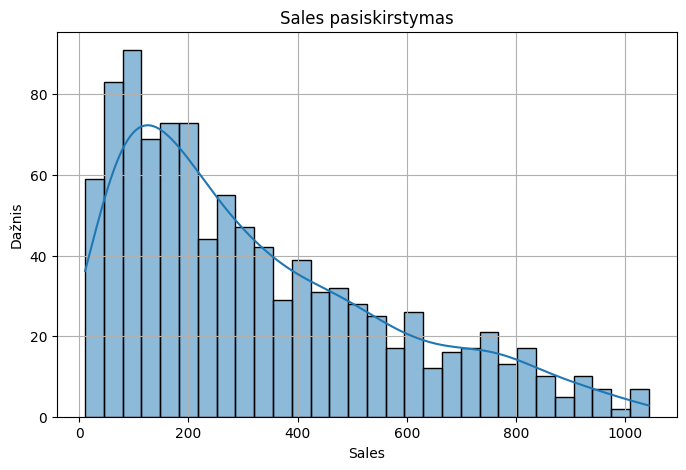

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df["Sales"], kde=True, bins=30)
plt.title("Sales pasiskirstymas")
plt.xlabel("Sales")
plt.ylabel("Dažnis")
plt.show()


Interpretacija:  
Sales histograma rodo, kad pardavimų pasiskirstymas yra aiškiai dešinėn pasviręs. Dauguma pirkimų yra mažos arba vidutinės vertės (apie 100–300), o dideli pirkimai virš 800–1000 pasitaiko retai. Tai patvirtina, kad pardavimai turi ilgą dešinę uodegą ir keletą outlierių, kurie kelia vidurkį aukštyn. KDE kreivė rodo vieną ryškų piką ties ~100–150, todėl tipinis pirkimo dydis yra būtent šiame intervale.

Sales pagal Branch:

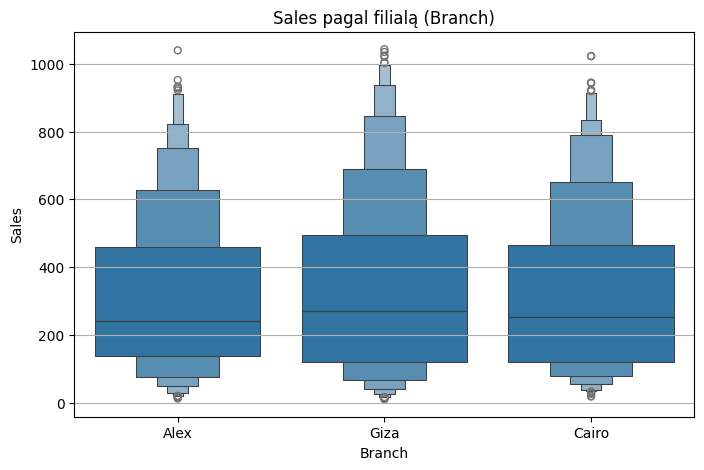

In [14]:
plt.figure(figsize=(8,5))
sns.boxenplot(data=df, x="Branch", y="Sales")
plt.title("Sales pagal filialą (Branch)")
plt.xlabel("Branch")
plt.ylabel("Sales")
plt.show()


Interpretacija:  
Boxen grafikas rodo, kad visų trijų filialų (Alex, Giza ir Cairo) pardavimų pasiskirstymas yra labai panašus. Pagrindinė pardavimų dalis (interkvartilinė sritis) yra beveik identiška visuose filialuose, todėl tipinis pirkimo dydis tarp filialų nesiskiria.

Tačiau visuose filialuose matomi išsiskiriantys taškai (outlieriai), kurie atspindi labai didelius pirkimus. Kai kuriuose filialuose (pvz., Cairo) šių didelių pirkimų yra šiek tiek daugiau, todėl jų pardavimų „uodega“ yra ilgesnė. Tai rodo, kad nors vidutiniai pardavimai filialuose panašūs, didelių pirkimų pasitaiko nevienodai.

Vidutiniai Sales pagal Product line:

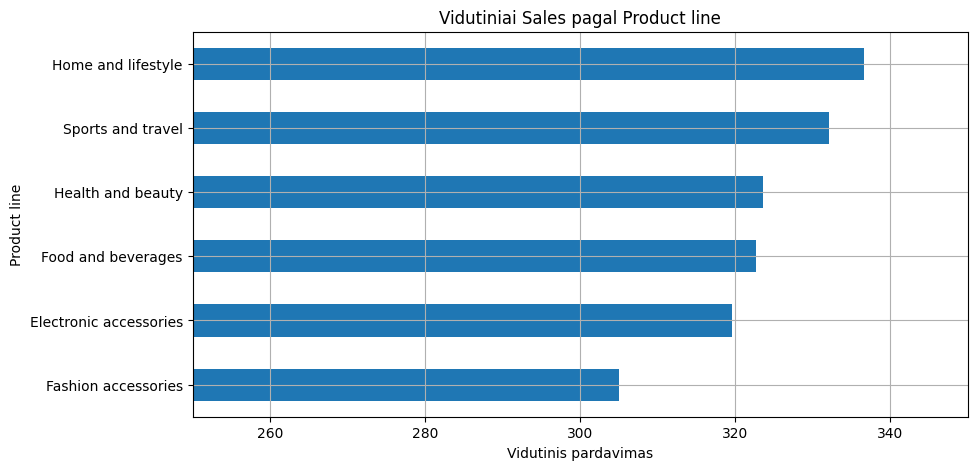

In [18]:
plt.figure(figsize=(10,5))
df.groupby("Product line")["Sales"].mean().sort_values().plot(kind="barh")
plt.title("Vidutiniai Sales pagal Product line")
plt.xlabel("Vidutinis pardavimas")
plt.ylabel("Product line")
plt.xlim(250, 350) 
plt.show()

Interpretacija:  
Iš grafiko matyti, kad didžiausi vidutiniai pardavimai yra „Home and lifestyle“ ir „Sports and travel“ produktų linijose, o mažiausi — „Fashion accessories“. Skirtumai tarp kategorijų nėra labai dideli, tačiau kai kurios linijos generuoja pastebimai didesnę vidutinę pardavimo vertę.

Sales pagal savaitės dienas:

C:\Users\modis\AppData\Local\Temp\ipykernel_17004\3189651765.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Weekday", y="Sales", estimator="mean", order=order, palette="rocket")


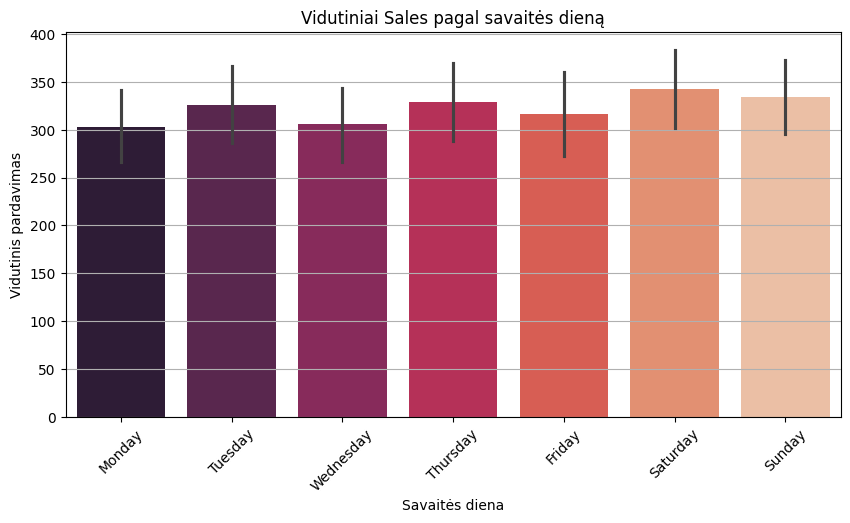

In [19]:
df["Weekday"] = df["Date"].dt.day_name()
plt.figure(figsize=(10,5))
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

sns.barplot(data=df, x="Weekday", y="Sales", estimator="mean", order=order, palette="rocket")
plt.title("Vidutiniai Sales pagal savaitės dieną")
plt.xlabel("Savaitės diena")
plt.ylabel("Vidutinis pardavimas")
plt.xticks(rotation=45)
plt.show()


Interpretacija:  
Iš grafiko matyti, kad didžiausi vidutiniai pardavimai vyksta savaitgaliais, ypač šeštadienį ir sekmadienį. Mažiausi pardavimai fiksuojami pirmadienį ir trečiadienį. Tai rodo, kad klientų aktyvumas savaitės eigoje nėra tolygus — savaitgaliais pirkėjų srautas ir pirkimų vertė yra didesni.

---

### 3. Pasikliautiniai intervalai

**Tikslas:**

- Pasirinkti vieną skaitinį kintamąjį (pvz., `Sales`, `gross income` arba `Rating`).
- Apskaičiuoti **95 % pasikliautinį intervalą (CI)** jo vidurkiui.
- Paaiškinti, kaip šį intervalą interpretuoti praktiniame kontekste.

Naudojamas t-skirstinys (`stats.t.ppf`) ir standartinė paklaida (SE).

### Sprendimas:

In [ ]:
# TODO: pasirinkti stulpelį ir apskaičiuoti 95 % CI
# col = "Sales"  # pakeisti pagal duomenis
# x = df[col].dropna().astype(float).values
# n = len(x)
# mean = x.mean()
# std = x.std(ddof=1)

# alpha = 0.05
# t_crit = stats.t.ppf(1 - alpha/2, df=n-1)
# se = std / np.sqrt(n)

# ci_low = mean - t_crit * se
# ci_high = mean + t_crit * se

# mean, (ci_low, ci_high), n

---

### 4. Hipotezių testavimas

**Tikslas:**

- Pasirinkti, teisingai atlikti ir aiškiai paaiškinti **bent vieną** statistinį hipotezių testą:
  - **t-test:** (2 grupės, skaitinis target). Pvz., vidutinės pirkimo sumos (`Sales`) palyginimas tarp `Customer type` (`Member` vs `Normal`).
  - **ANOVA:** (3+ grupės, skaitinis target). Pvz., vidutinių pardavimų ar pajamų palyginimas tarp `Branch`.
  - **Chi-square:** (2 kategoriniai). Pvz., ryšio tarp dviejų kategorinių kintamųjų (pvz., `Payment` ir `Gender`) įvertinimas
- Aiškiai suformuluoti **H0** ir **Ha**.
- Pateikti **p reikšmę**.
- Pateikti išvadas ir interpretaciją paprastais žodžiais.
- Papildomai nurodyti **praktinį efektą** (pvz., vidurkių skirtumą).

### Sprendimas:

In [ ]:
# TODO (pasirinktinai): t-test (Welch)
# H0: vidurkiai vienodi
# Ha: vidurkiai skiriasi
#
# target = "Sales"
# group = "Customer type"
#
# g1 = df.loc[df[group] == "Member", target].dropna().astype(float)
# g2 = df.loc[df[group] == "Normal", target].dropna().astype(float)
#
# t_stat, p_val = stats.ttest_ind(g1, g2, equal_var=False)
# diff_means = g1.mean() - g2.mean()
# t_stat, p_val, diff_means

In [ ]:
# TODO (pasirinktinai): ANOVA
# H0: visų grupių vidurkiai vienodi
# Ha: bent vienos grupės vidurkis skiriasi
#
# target = "Sales"
# group = "Branch"
#
# groups = [g.dropna().astype(float).values for _, g in df.groupby(group)[target]]
# f_stat, p_val = stats.f_oneway(*groups)
# f_stat, p_val

In [ ]:
# TODO (pasirinktinai): Chi-square
# H0: kintamieji nepriklausomi
# Ha: kintamieji priklausomi
#
# cat1 = "Payment"
# cat2 = "Gender"
#
# ct = pd.crosstab(df[cat1], df[cat2])
# chi2, p_val, dof, expected = stats.chi2_contingency(ct)
# chi2, p_val, dof

---

### 5. Analitinė dalis

### 5.A. Regresinė analizė

**Tikslas:**

- Pasirinkti target kintamąjį (pvz., `Sales`).
- Paruošti **X** ir **y**.
- Pasirinkti bent **5–8 features** (skaitinius ir kategorinius).
- Kategorinius kintamuosius paversti į dummy kintamuosius naudojant `drop_first=True`.
- **SVARBU:** po `get_dummies` naudoti `.astype(float)`, kad būtų užtikrintas suderinamumas su OLS modeliu, nekiltų `ValueError`.
- Padalinti duomenis į mokymo ir testavimo rinkinius (pvz., 80/20).
- Sukurti ir apmokyti regresijos modelį naudojant **statsmodels OLS**.
- Įvertinti modelio kokybę testavimo rinkinyje su **R²**, **MAE**, **RMSE**.
- Trumpai interpretuoti rezultatus: 2–3 svarbiausius koeficientus, ką tai reiškia verslo prasme.

### Sprendimas:

In [ ]:
# TODO: pasirinkti target ir features
# target = "Sales"
# feature_cols = ["Unit price", "Quantity", "Branch", "City", "Customer type", "Gender", "Product line", "Payment"]

# X_raw = df[feature_cols].copy()
# y = df[target].astype(float)

# Dummy + float (kritiška dėl ValueError)
# X = pd.get_dummies(X_raw, drop_first=True).astype(float)

# Train/test split
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# OLS modelio apmokymas
# model = sm.OLS(y_train, sm.add_constant(X_train)).fit()
# model.summary()

In [ ]:
# TODO: prognozės ir metrikos ant test rinkinio
# pred_test = model.predict(sm.add_constant(X_test))

# r2 = r2_score(y_test, pred_test)
# mae = mean_absolute_error(y_test, pred_test)
# rmse = mean_squared_error(y_test, pred_test) ** 0.5

# {"R2_test": r2, "MAE_test": mae, "RMSE_test": rmse}

---

### 5.B. Laiko eilučių analizė

**Tikslas:**

- Įvertinti pardavimų dinamiką laike, naudojant agreguotus pardavimus (`Sales`) pagal laiką (dienas arba mėnesius).
- Konvertuoti datą į `datetime` formatą (jei reikia).
- Sukurti laiko eilutę: agreguoti `Sales` (ar kitą pardavimų metriką) pagal datą (dienas arba mėnesius).
- Pavaizduoti pardavimų dinamiką (laiko eilutę) grafike.
- Aprašyti pastebėtas tendencijas, sezoniškumą ar šuolius.
- Pateikti nesudėtingą prognozės pavyzdį, naudojant **slenkantį vidurkį** (_Moving Average_) arba paskutinių N periodų vidurkį kaip „forecast“.
- **SVARBU:** Sudėtingi modeliai (ARIMA/Prophet) nebūtini.

### Sprendimas:

In [ ]:
# TODO: paruošti datą ir agreguoti pardavimus
# df["Date"] = pd.to_datetime(df["Date"])
# ts = df.groupby("Date")["Sales"].sum().sort_index()
# ts.head()

In [ ]:
# TODO: laiko eilutės grafikas
# ts.plot(title="Pardavimai laike (dienos suma)")
# plt.xlabel("Data")
# plt.ylabel("Sales")
# plt.show()

In [ ]:
# TODO: paprasta prognozė su slenkančiu vidurkiu
# window = 7
# ts_ma = ts.rolling(window=window).mean()

# plt.figure()
# plt.plot(ts.index, ts.values, label="Tikros reikšmės")
# plt.plot(ts_ma.index, ts_ma.values, label=f"{window} d. slenkantis vidurkis")
# plt.title("Pardavimai ir slenkantis vidurkis")
# plt.xlabel("Data")
# plt.ylabel("Sales")
# plt.legend()
# plt.show()

---

### 6. Išvados

**Tikslas:**


- Apibendrinti pagrindinius analizės rezultatus:
  - Trumpai apibendrinti **EDA radinius** (2–4 punktai).
  - Pateikti **95 % pasikliautinio intervalo (CI)** interpretaciją (1–2 sakiniai).
  - Pateikti **hipotezių testo išvadą** (**H0/Ha**, **p reikšmė** ir interpretacija).
  - Apibendrinti **regresinės analizės** rezultatus (metrikos ir 2–3 koeficientų prasmė).
  - Apibendrinti **laiko eilučių analizę** (tendencijos + paprastos prognozės mintis).
- Paaiškinti, kuo šios įžvalgos gali būti naudingos verslui, ir pateikti **2–3 rekomendacijas** (verslui).
- Parengti aiškias ir trumpas išvadas / dokumentaciją PDF arba MS Word formatu (1-3 puslapiai).

### Sprendimas:

In [ ]:
# TODO
# ...
# ...
# ...

---